In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [57]:
df = pd.read_csv(r'C:\Users\jenar\!clases\TC2034-Jenaro\most_viewed_videos_1000.csv')
df.head(10)

,rank,title,title_length,detected_language,content_type,is_short,has_hashtags,views,likes
0,1,Baby Shark Dance | #babyshark Most Viewed Vide...,92,English,Kids/Educational,0,1,16.8B,46.4M
1,2,Luis Fonsi - Despacito ft. Daddy Yankee,39,English,Music Video,0,0,8.97B,56.0M
2,3,Wheels on the Bus | @CoComelon Nursery Rhymes ...,58,English,Kids/Educational,0,0,8.71B,21.9M
3,4,Bath Song | @CoComelon Nursery Rhymes & Kids S...,50,English,Kids/Educational,0,0,7.41B,17.4M
4,5,Johny Johny Yes Papa 👶 THE BEST Song for Child...,76,English,Kids/Educational,0,0,7.16B,19.3M
5,6,Wiz Khalifa - See You Again ft. Charlie Puth [...,82,English,Music Video,0,0,6.95B,46.3M
6,7,Phonics Song with TWO Words - A For Apple - AB...,87,English,Kids/Educational,0,0,6.92B,0
7,8,Ed Sheeran - Shape of You (Official Music Video),48,English,Music Video,0,0,6.69B,35.4M
8,9,PSY - GANGNAM STYLE(강남스타일) M/V,30,Korean,Other,0,0,5.89B,31.6M
9,10,Crazy Frog - Axel F (Official Video),36,English,Music Video,0,0,5.82B,21.3M


In [58]:
print(df.shape)
df.info()

(1000, 9)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   rank               1000 non-null   int64
 1   title              1000 non-null   str  
 2   title_length       1000 non-null   int64
 3   detected_language  1000 non-null   str  
 4   content_type       1000 non-null   str  
 5   is_short           1000 non-null   int64
 6   has_hashtags       1000 non-null   int64
 7   views              1000 non-null   str  
 8   likes              1000 non-null   str  
dtypes: int64(4), str(5)
memory usage: 70.4 KB


In [59]:
df.isna().sum()

rank                 0
title                0
title_length         0
detected_language    0
content_type         0
is_short             0
has_hashtags         0
views                0
likes                0
dtype: int64

In [60]:
def parse_value(val):
    val = str(val).strip()
    if val.endswith('B'):
        return int(float(val[:-1]) * 1_000_000_000)
    elif val.endswith('M'):
        return int(float(val[:-1]) * 1_000_000)
    elif val.endswith('K'):
        return int(float(val[:-1]) * 1_000)
    else:
        return int(float(val))

df['views'] = df['views'].apply(parse_value)
df['likes'] = df['likes'].apply(parse_value)
df[['views', 'likes']].head()

,views,likes
0,16800000000,46400000
1,8970000000,56000000
2,8710000000,21900000
3,7410000000,17400000
4,7160000000,19300000


In [61]:
df['detected_language'].value_counts()

detected_language
English     919
Korean       21
Hindi        20
Arabic       20
Russian      11
Chinese       4
Tamil         3
Bengali       1
Japanese      1
Name: count, dtype: int64

In [62]:
df['content_type'].value_counts()

content_type
Music Video             400
Other                   286
Kids/Educational        159
Short                    69
Ad/Promo                 57
Challenge/Experiment      9
Tutorial/Educational      8
Comedy/Entertainment      4
Film/Documentary          3
Live Stream               2
Fitness                   1
Food/Cooking              1
Vlog                      1
Name: count, dtype: int64

In [63]:
df = pd.get_dummies(df, columns=['detected_language', 'content_type'], drop_first=False, dtype=int)
df.head()

,rank,title,title_length,is_short,has_hashtags,views,likes,detected_language_Arabic,detected_language_Bengali,detected_language_Chinese,...,content_type_Film/Documentary,content_type_Fitness,content_type_Food/Cooking,content_type_Kids/Educational,content_type_Live Stream,content_type_Music Video,content_type_Other,content_type_Short,content_type_Tutorial/Educational,content_type_Vlog
0,1,Baby Shark Dance | #babyshark Most Viewed Vide...,92,0,1,16800000000,46400000,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1,2,Luis Fonsi - Despacito ft. Daddy Yankee,39,0,0,8970000000,56000000,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,3,Wheels on the Bus | @CoComelon Nursery Rhymes ...,58,0,0,8710000000,21900000,0,0,0,...,0,0,0,1,0,0,0,0,0,0
3,4,Bath Song | @CoComelon Nursery Rhymes & Kids S...,50,0,0,7410000000,17400000,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,5,Johny Johny Yes Papa 👶 THE BEST Song for Child...,76,0,0,7160000000,19300000,0,0,0,...,0,0,0,1,0,0,0,0,0,0


In [64]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 29 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   rank                               1000 non-null   int64
 1   title                              1000 non-null   str  
 2   title_length                       1000 non-null   int64
 3   is_short                           1000 non-null   int64
 4   has_hashtags                       1000 non-null   int64
 5   views                              1000 non-null   int64
 6   likes                              1000 non-null   int64
 7   detected_language_Arabic           1000 non-null   int64
 8   detected_language_Bengali          1000 non-null   int64
 9   detected_language_Chinese          1000 non-null   int64
 10  detected_language_English          1000 non-null   int64
 11  detected_language_Hindi            1000 non-null   int64
 12  detected_language_Japanese      

## EDA

In [65]:
df.describe()

,rank,title_length,is_short,has_hashtags,views,likes,detected_language_Arabic,detected_language_Bengali,detected_language_Chinese,detected_language_English,...,content_type_Film/Documentary,content_type_Fitness,content_type_Food/Cooking,content_type_Kids/Educational,content_type_Live Stream,content_type_Music Video,content_type_Other,content_type_Short,content_type_Tutorial/Educational,content_type_Vlog
count,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1.000000e+03,1000.00000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,54.363000,0.069000,0.099000,1.783920e+09,9.344834e+06,0.02000,0.001000,0.004000,0.919000,...,0.003000,0.001000,0.001000,0.159000,0.002000,0.400000,0.286000,0.069000,0.008000,0.001000
std,288.819436,21.390624,0.253581,0.298811,1.039060e+09,7.530783e+06,0.14007,0.031623,0.063151,0.272972,...,0.054717,0.031623,0.031623,0.365859,0.044699,0.490143,0.452115,0.253581,0.089129,0.031623
min,1.000000,6.000000,0.000000,0.000000,1.010000e+09,0.000000e+00,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,250.750000,39.000000,0.000000,0.000000,1.180000e+09,4.177499e+06,0.00000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,500.500000,52.000000,0.000000,0.000000,1.465000e+09,7.160000e+06,0.00000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,750.250000,67.250000,0.000000,0.000000,1.992500e+09,1.262500e+07,0.00000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000
max,1000.000000,100.000000,1.000000,1.000000,1.680000e+10,5.760000e+07,1.00000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


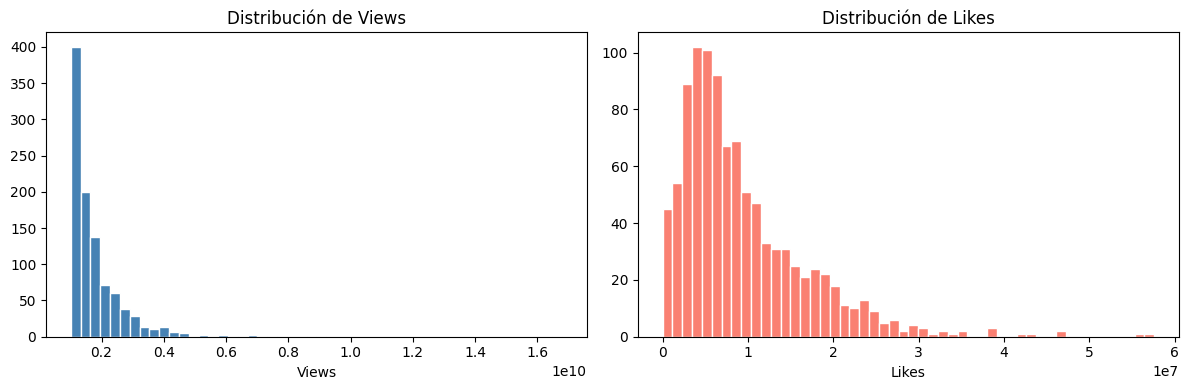

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['views'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de Views')
axes[0].set_xlabel('Views')

axes[1].hist(df['likes'], bins=50, color='salmon', edgecolor='white')
axes[1].set_title('Distribución de Likes')
axes[1].set_xlabel('Likes')

plt.tight_layout()
plt.show()

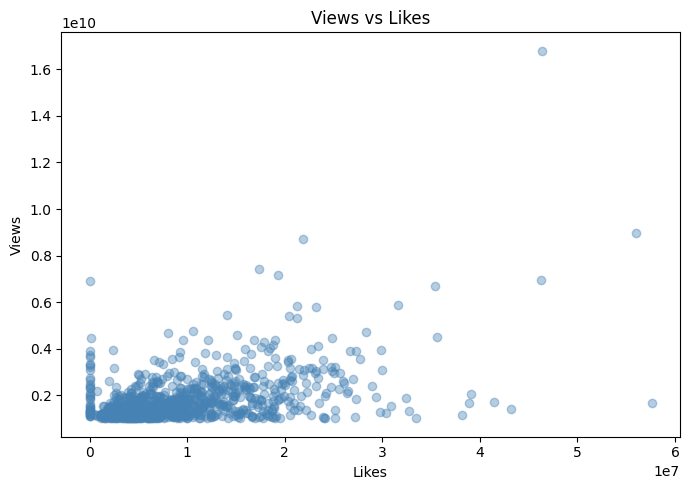

In [67]:
plt.figure(figsize=(7, 5))
plt.scatter(df['likes'], df['views'], alpha=0.4, color='steelblue')
plt.title('Views vs Likes')
plt.xlabel('Likes')
plt.ylabel('Views')
plt.tight_layout()
plt.show()

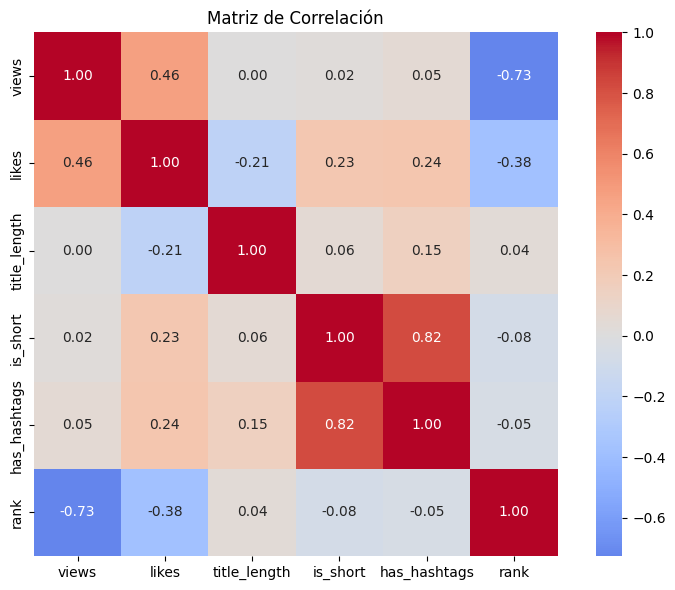

In [68]:
cols_corr = ['views', 'likes', 'title_length', 'is_short', 'has_hashtags', 'rank']
corr = df[cols_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Matriz de Correlación')
plt.tight_layout()
plt.show()

In [69]:
numeric_cols = df.select_dtypes(include='number').drop(columns=['rank']).columns.tolist()
X_vif = df[numeric_cols].dropna()

vif = pd.DataFrame({
    'Feature': numeric_cols,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

vif

,Feature,VIF
0,detected_language_Hindi,2.434378e+14
1,detected_language_Korean,9.191020e+13
2,content_type_Kids/Educational,3.194042e+13
3,content_type_Music Video,1.827018e+13
4,content_type_Film/Documentary,1.643649e+13
5,content_type_Ad/Promo,1.348383e+13
6,content_type_Other,9.779804e+12
7,content_type_Short,2.222902e+12
8,is_short,1.150198e+12
9,detected_language_English,1.108442e+12


## Modelo de Regresión Lineal

**Variable objetivo:** `likes`

**Variables predictoras seleccionadas:**
- `views` — mayor predictor de engagement; se descarta `rank` por alta correlación con views (multicolinealidad)
- `title_length` — longitud del título como proxy de estrategia de contenido
- `is_short` — los YouTube Shorts tienen patrones de likes distintos
- `has_hashtags` — influye en el alcance del video
- Dummies de `content_type` — distintos géneros tienen ratios likes/views muy diferentes

Se aplica `np.log1p()` a `views` y `likes` para corregir el sesgo positivo de sus distribuciones.

In [ ]:
content_dummies = [c for c in df.columns if c.startswith('content_type_')]

feature_cols = ['views', 'title_length', 'is_short', 'has_hashtags'] + content_dummies

X = df[feature_cols].copy()
X['views'] = np.log1p(X['views'])

y = np.log1p(df['likes'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

In [71]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [ ]:
y_pred_log = model.predict(X_test)

# convertir de vuelta a escala original para métricas interpretables
y_pred_orig = np.expm1(y_pred_log)
y_test_orig = np.expm1(y_test)

r2  = r2_score(y_test, y_pred_log)
mae = mean_absolute_error(y_test_orig, y_pred_orig)
rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))

print(f'R² (escala log):        {r2:.4f}')
print(f'MAE  (likes reales):    {mae:,.0f}')
print(f'RMSE (likes reales):    {rmse:,.0f}')
print(f'Media likes (test):     {y_test_orig.mean():,.0f}')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred_log, alpha=0.4, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel('Likes reales (log)')
axes[0].set_ylabel('Likes predichos (log)')
axes[0].set_title('Predicho vs Real')

residuals = y_test - y_pred_log
axes[1].scatter(y_pred_log, residuals, alpha=0.4, color='salmon')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Likes predichos (log)')
axes[1].set_ylabel('Residuales')
axes[1].set_title('Residuales vs Predicho')

plt.tight_layout()
plt.show()